# Chapter 1. Four readings of sales

**Week 1, Monday. Chapter 1 of 6: which total is "sales", and which one goes beside Meera's
plan?**

**The need.** Kalpa Retail grew revenue 4 percent last year against a plan of 15, and
marketing wants Rs 12 crore to acquire customers. Meera Raghavan, the CEO, asks the team:

> "Before I sign anything, I want to understand our own sales. What is 'sales' made of? Where
> does revenue come from, by customer type and channel? Is acquisition even the branch that is
> short?"

| | |
|---|---|
| The metric at stake | Sales, the base every growth percentage is measured from |
| Who asks | Meera Raghavan, CEO, and behind her Anand Iyer, the finance controller, whose books the number must match |
| What a wrong number costs | A growth plan measured from demand that never became a sale, and a store baseline inflated by orders nobody kept |
| A real company with the same question | Reliance Retail reported gross revenue of Rs 90,408 crore and revenue from operations of Rs 79,745 crore for the same quarter to June 2026, with GST recovered as the step between them (Reliance Industries media release, 17 July 2026). Two honest totals for one quarter is normal in retail. |
| In the dossier (`study-notes/C2_W01_D01_domain_retail_STUDENT.md`) | Section 3, how the business makes money: GMV walked to net revenue, and why two correct totals exist for one quarter |

The story walked Rs 100 of GMV down to net revenue. This chapter does the same walk on Kalpa's
own 30 orders, from 1 July to 26 September 2026, and settles which total earns the word
"sales".

> **Kavya's review.** Every number you bring me today carries its definition beside it.
> "Sales is five lakh" is a rumour. "Booked sales on 30 orders, cancellations included" is a
> number I can take into Meera's room.

**Setup.** The first cell finds the shared helper, `c2kit`, and loads the 30 orders from
`../data/` as `ORDERS`, a list of dictionaries, one per order. Run it again after any kernel
restart.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

first_day = min(order["order_date"] for order in ORDERS)
last_day = max(order["order_date"] for order in ORDERS)
print(len(ORDERS), "orders loaded, dated", first_day, "to", last_day)

30 orders loaded, dated 2026-07-01 to 2026-09-26


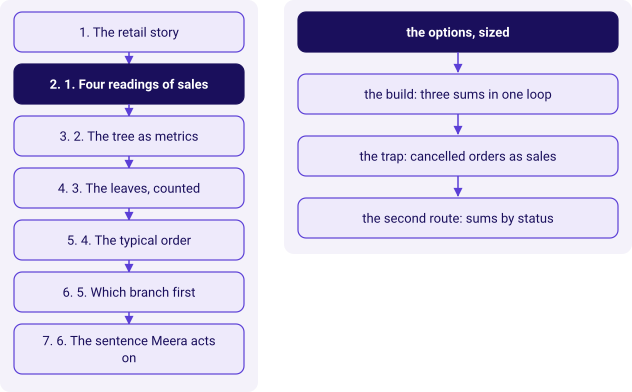

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=1, show=False),
    kit.vflow(['the options, sized', 'the build: three sums in one loop', 'the trap: cancelled orders as sales', 'the second route: sums by status'], lit=0, show=False),
)

## The options

Four ways a team could answer "what are our sales?", each sized on this file.

| Option | Rows touched | Time | Error on this file | When it is the right call |
|---|---|---|---|---|
| A. Add every amount and send the total | 30 | under a second | counts every cancelled order as a sale | never alone; it is the booked reading, and needs its name |
| B. Sum by status, report booked, not cancelled and delivered, with the bridge between them | 30, once | under a second | none once the bridge lands | a CEO's first look, when the plan's definition is not yet known |
| C. Ask Finance for the figure in the books | none | a day or more | none, on Finance's definition | when the number goes to the board and must match the books |
| D. Tick orders off by hand in a spreadsheet | 30 | about ten minutes | a typo in one of 30 cells | never at 30 rows; impossible at 30 lakh |

**The best-fit call.** B: one pass gives all three readings, and the bridge names every rupee
between them, so Meera sees which total she is reading. **What would change it:** if Finance
has already fixed the definition the 15 percent plan was set on, C decides which of B's
three totals goes in the note, and B's bridge explains the gap to the others.

The cell below measures option A's error before any build: it counts the orders whose status
says they never became a sale.

option,rows touched,orders it counts that never became a sale
A. add every amount,30,4
"B. sum by status, with the bridge",30,0
C. Finance's books,0,Finance's definition
D. by hand,30,"0, if no typo"


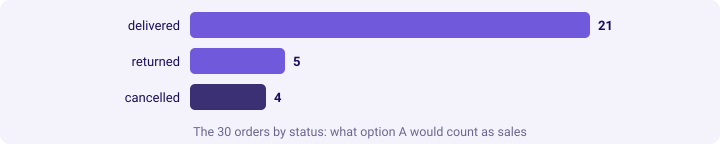

In [3]:
statuses = {}
for order in ORDERS:
    statuses[order["status"]] = statuses.get(order["status"], 0) + 1
kit.table(["option", "rows touched", "orders it counts that never became a sale"],
          [("A. add every amount", len(ORDERS), statuses["cancelled"]),
           ("B. sum by status, with the bridge", len(ORDERS), 0),
           ("C. Finance's books", 0, "Finance's definition"),
           ("D. by hand", len(ORDERS), "0, if no typo")],
          caption="The four options, sized on this file")
kit.bars([(s, n) for s, n in statuses.items()], lit=(2,),
         title="The 30 orders by status: what option A would count as sales")
kit.check("the file holds 30 orders", len(ORDERS) == 30)
kit.check("some orders never became sales", statuses["cancelled"] > 0, statuses)

## 1. The build: one loop keeps three sums

One Kalpa order is a dictionary of seven named fields. The field that splits the readings of
sales is `status`: delivered, returned after delivery, or cancelled before it left.

The first loop adds every amount to a running total, the way anyone would first write it. The
`with kit.expect_error()` line catches an error, if one comes, so the notebook keeps running.

In [4]:
with kit.expect_error() as stopped:
    booked = 0
    for order in ORDERS:
        booked += order["amount"]
    print(len(ORDERS), booked)

**What happened.** The loop stopped. The last line reads `TypeError: unsupported operand
type(s) for +=: 'int' and 'str'`: a whole number on the left, text on the right, and Python
will not add text to a number. One amount in the file is stored as text. That gets two
minutes and no more.

**Your turn.** The loop stopped on a record, and `order` still holds it. Type these two lines
into the empty cell below and say what is odd about the record:

```python
print(order)
print(type(order["amount"]))
```

**The fix for today** is `int()`, which turns text that looks like a whole number into a
number. Why an amount arrived as text, and whether a larger file holds more, is Wednesday's
question. Now the build proper: one loop, three sums.

**Predict before you run.** Which rupee reading comes out largest?

- a) Delivered, because only delivered orders are real.
- b) Not cancelled, because it keeps returns and deliveries.
- c) Booked, because it keeps every order.
- d) All three are equal.

reading of sales,what it keeps,value
order count,every row,30
booked,every order placed,"Rs 5,44,810"
not cancelled,"orders that left the shelf, returns included","Rs 5,35,760"
delivered,orders that reached a customer and stayed,"Rs 5,20,790"


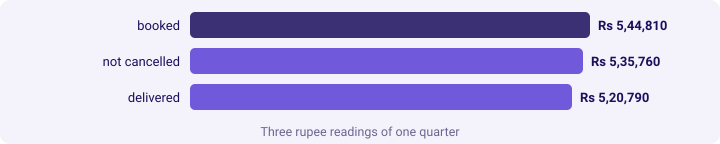

In [5]:
readings = {"orders": 0, "booked": 0, "not cancelled": 0, "delivered": 0}
for order in ORDERS:
    amount = int(order["amount"])
    readings["orders"] += 1
    readings["booked"] += amount
    if order["status"] != "cancelled":
        readings["not cancelled"] += amount
    if order["status"] == "delivered":
        readings["delivered"] += amount
kit.table(["reading of sales", "what it keeps", "value"],
          [("order count", "every row", readings["orders"]),
           ("booked", "every order placed", kit.rupees(readings["booked"])),
           ("not cancelled", "orders that left the shelf, returns included", kit.rupees(readings["not cancelled"])),
           ("delivered", "orders that reached a customer and stayed", kit.rupees(readings["delivered"]))],
          caption="Four readings of sales on the same 30 orders")
kit.bars([(k, readings[k]) for k in ("booked", "not cancelled", "delivered")], fmt=kit.rupees,
         lit=(0,), title="Three rupee readings of one quarter")

In [6]:
kit.check("the loop visited all 30 orders", readings["orders"] == 30)
kit.check("booked sales is Rs 5,44,810", readings["booked"] == 544810, kit.rupees(readings["booked"]))
kit.check("each narrower reading keeps less",
          readings["booked"] >= readings["not cancelled"] >= readings["delivered"])

**What happened.** The answer is c. Booked is Rs 5,44,810, not cancelled Rs 5,35,760 and
delivered Rs 5,20,790. The order count, 30, is the fourth reading and answers how many times
somebody decided to buy.

## 2. The trap: cancelled orders reported as sales

**Predict before you run.** Of the 30 orders in the booked total, how many never left the shelf?

- a) None, since every row is an order.
- b) Nine, the returns and the cancellations.
- c) Five, the orders that came back.
- d) Four, the orders cancelled before they left.

**The plausible wrong answer.** The hurried analyst's line, exactly as it would be sent:

In [7]:
print("Sales this quarter:", kit.rupees(readings["booked"]), "on", readings["orders"], "orders")

Sales this quarter: Rs 5,44,810 on 30 orders


**Why it is wrong.** A cancelled order never left the shelf and never paid Kalpa a rupee, so it
is demand that never arrived. Sent as "sales", it overstates the base Meera's 15 percent plan
is measured from and the channel it sits in. The check counts orders by channel and status
before adding anything.

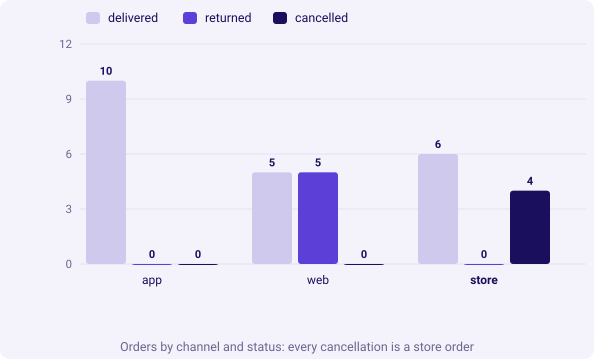

In [8]:
grid = {}
for order in ORDERS:
    key = (order["channel"], order["status"])
    grid[key] = grid.get(key, 0) + 1
channels = ["app", "web", "store"]
kit.columns(channels, [(s, [grid.get((c, s), 0) for c in channels])
                       for s in ["delivered", "returned", "cancelled"]],
            lit=(2,), title="Orders by channel and status: every cancellation is a store order")
cancelled_channels = {c for (c, s) in grid if s == "cancelled"}
kit.check("the statuses split 21 delivered, 5 returned, 4 cancelled",
          (statuses["delivered"], statuses["returned"], statuses["cancelled"]) == (21, 5, 4))
kit.check("every cancelled order is a store order", cancelled_channels == {"store"})

**The fix, and what changed.** The answer is d. Write the definition beside the number and show
the walk between the readings: taking out the cancellations moves Rs 9,050 and 4 store orders
out of sales; taking out the returns moves another Rs 14,970 and 5 web orders. Store's 10
orders overstate its kept orders by 4 in 10.

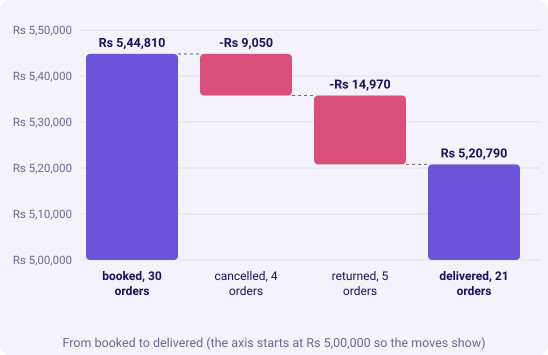

In [9]:
kit.bridge(("booked, 30 orders", readings["booked"]),
           [("cancelled, 4 orders", readings["not cancelled"] - readings["booked"]),
            ("returned, 5 orders", readings["delivered"] - readings["not cancelled"])],
           end_label="delivered, 21 orders", lo=500000,
           title="From booked to delivered (the axis starts at Rs 5,00,000 so the moves show)")
kit.check("cancelled orders carry Rs 9,050", readings["booked"] - readings["not cancelled"] == 9050)
kit.check("returned orders carry Rs 14,970", readings["not cancelled"] - readings["delivered"] == 14970)

## A second route: sums by status, then combine

The same three totals come out of a dictionary that adds rupees under each status, after which
each reading is a sum of statuses. If the two routes disagree, one of them has a bug.

In [10]:
by_status = {}
for order in ORDERS:
    by_status[order["status"]] = by_status.get(order["status"], 0) + int(order["amount"])
second = {"booked": sum(by_status.values()),
          "not cancelled": by_status["delivered"] + by_status["returned"],
          "delivered": by_status["delivered"]}
kit.table(["reading", "one loop, three sums", "sums by status, combined"],
          [(k, kit.rupees(readings[k]), kit.rupees(second[k])) for k in second],
          caption="Two routes to the same three totals")
for k in second:
    kit.check(f"{k}: both routes agree", second[k] == readings[k], kit.rupees(second[k]))

reading,"one loop, three sums","sums by status, combined"
booked,"Rs 5,44,810","Rs 5,44,810"
not cancelled,"Rs 5,35,760","Rs 5,35,760"
delivered,"Rs 5,20,790","Rs 5,20,790"


**When to switch.** The status dictionary is the better route when a fourth status appears
(a part-refund, say), since it needs no new `if`; the one-loop route is clearer when a reader
must see each definition written out. At a million rows either becomes one `GROUP BY status`
in SQL, which Week 2 teaches.

> **Kavya's review.** You found Rs 9,050 that was never a sale, and you found it by counting
> before adding. Which definition Meera plans on is her call; your job is to make sure she can
> see which one she is reading.

### In the interview

**[F] What counts as "sales": booked, net of cancellations, or delivered, and which do you give
a CEO?** "All three are legitimate and answer different questions: booked is demand, net of
cancellations is what left the shelf, delivered is what stayed sold. On Kalpa's quarter they
were Rs 5,44,810, Rs 5,35,760 and Rs 5,20,790. I give the CEO the one her plan was set on, say
it beside the number, and show the bridge so the gaps are named. Reliance Retail publishes
gross revenue and revenue from operations for the same quarter for the same reason."

**[D] How would you decide between summing the file yourself and asking Finance for the
number?** "By who acts on it. For a first look I sum by status in one pass, which takes a
second and shows every reading. For anything that reaches the board I reconcile to Finance's
figure, because a number that disagrees with the books loses the room whatever its logic."

### Depth: what a fourth status would do

A part-refunded order would sit between delivered and returned. The status route absorbs it
with no new code; the one-loop route needs a new `if` for every reading it touches. That is
the general rule: when the categories may grow, group by the category.

## What this chapter established

What we now know,The evidence
Sales has four readings; the definition goes beside the number,"Rs 5,44,810 booked, Rs 5,35,760 not cancelled, Rs 5,20,790 delivered"
"Cancelled orders are demand that never arrived, all in store","Rs 9,050 on 4 orders"
"One amount is text, and int() fixes it for today","the TypeError, met in two minutes"


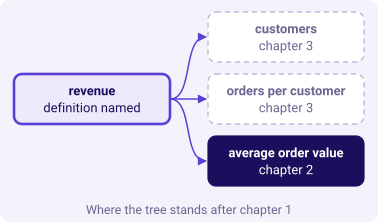

Next: chapter 2 turns each branch of the tree into a metric with a numerator and a denominator.


In [11]:
kit.table(["What we now know", "The evidence"],
          [("Sales has four readings; the definition goes beside the number",
            "Rs 5,44,810 booked, Rs 5,35,760 not cancelled, Rs 5,20,790 delivered"),
           ("Cancelled orders are demand that never arrived, all in store", "Rs 9,050 on 4 orders"),
           ("One amount is text, and int() fixes it for today", "the TypeError, met in two minutes")],
          caption="Chapter 1: four readings of sales")
kit.driver_tree({"label": "revenue", "note": "definition named", "kind": "known", "children": [
    {"label": "customers", "note": "chapter 3", "kind": "unknown"},
    {"label": "orders per customer", "note": "chapter 3", "kind": "unknown"},
    {"label": "average order value", "note": "chapter 2", "kind": "lit"}]},
    title="Where the tree stands after chapter 1")
kit.check_summary()
print("Next: chapter 2 turns each branch of the tree into a metric with a numerator and a denominator.")